# Ghana Financial Inclusion Analysis

## The Global Findex Database 2025

**Country:** Ghana  
**Survey year:** 2024  
**Data source:** [World Bank Global Findex Ghana microdata](https://microdata.worldbank.org/catalog/7908)  
**Reference ID:** `GHA_2024_FINDEX_v02_M`  

### Research focus

This notebook studies financial inclusion and digital financial services in Ghana, with particular attention to mobile-money accounts, formal financial accounts, savings, borrowing, digital accounts and socioeconomic differences.

### Research questions

1. What are the main patterns of financial inclusion in the Ghana sample?
2. How does account ownership vary by gender, income quintile, education, employment and residence?
3. Which characteristics are associated with ownership of any financial account after adjustment for other observed characteristics?

## 1. Setup

The notebook is designed to work with the World Bank CSV export. It discovers a suitable file in `../raw-data/`, `/content/`, or the current working directory. If no file is found, the notebook stops with a clear instruction rather than creating fabricated results.

In [17]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
except ImportError:
    sm = None
    smf = None

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

# Optional override. Examples: Path("/content/Findex_Microdata_2025_updateGhana.dta")
DATA_PATH = None

def find_data_file():
    if DATA_PATH is not None:
        path = Path(DATA_PATH)
        if path.exists():
            return path
        raise FileNotFoundError(f"DATA_PATH does not exist: {path}")
    roots = [PROJECT_ROOT / "raw-data", Path("/content"), Path.cwd(), PROJECT_ROOT / "data"]
    candidates = []
    for root in roots:
        if root.exists():
            candidates.extend(root.glob("*.dta"))
            candidates.extend(root.glob("*.csv"))
    candidates = [p for p in candidates if "financial_inclusion_analysis" not in p.name]
    if not candidates:
        raise FileNotFoundError(
            "No .dta or .csv file found. Download the Ghana Global Findex file locally, "
            "set DATA_PATH to its path, and run this cell again. The raw file is intentionally not committed."
        )
    return sorted(candidates)[0]

DATA_FILE = find_data_file()
print(f"Using data file: {DATA_FILE}")

Using data file: /Users/mac/Desktop/MyLabs/Findex_Microdata_2025_updateGhana.csv


In [18]:
# Load the raw file without modifying it
if DATA_FILE.suffix.lower() == ".dta":
    df = pd.read_stata(DATA_FILE, convert_categoricals=False)
elif DATA_FILE.suffix.lower() == ".csv":
    df = pd.read_csv(DATA_FILE)
else:
    raise ValueError("Expected a .dta or .csv file")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1000, 199)


,year,economy,economycode,regionwb,pop_adult,wpid_random,wgt,female,age,educ,...,fin48e,fin48f,fin49a,fin49b,fin49c,fin49d,fin49e,fin49f,fin50,fin51
0,2024,Ghana,GHA,Sub-Saharan Africa (excluding high income),21563813,111377352,1.757570,1,45,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,Ghana,GHA,Sub-Saharan Africa (excluding high income),21563813,111425422,0.905216,1,37,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024,Ghana,GHA,Sub-Saharan Africa (excluding high income),21563813,111524531,3.010035,1,53,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024,Ghana,GHA,Sub-Saharan Africa (excluding high income),21563813,111573128,0.954274,1,23,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024,Ghana,GHA,Sub-Saharan Africa (excluding high income),21563813,111729119,0.900292,1,35,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Inspect the dataset

The official Ghana data dictionary reports **1,000 cases and 199 variables** for this file. The checks below use the actual file loaded locally and should be treated as the authoritative result if the file version changes.

In [20]:
print("Shape:", df.shape)
print("Number of variables:", len(df.columns))
print("First five rows:")
display(df.head())

Shape: (1000, 199)
Number of variables: 199
First five rows:


,year,economy,economycode,regionwb,pop_adult,wpid_random,wgt,female,age,educ,...,fin48e,fin48f,fin49a,fin49b,fin49c,fin49d,fin49e,fin49f,fin50,fin51
0,2024,Ghana,GHA,Sub-Saharan Africa (excluding high income),21563813,111377352,1.757570,1,45,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,Ghana,GHA,Sub-Saharan Africa (excluding high income),21563813,111425422,0.905216,1,37,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024,Ghana,GHA,Sub-Saharan Africa (excluding high income),21563813,111524531,3.010035,1,53,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024,Ghana,GHA,Sub-Saharan Africa (excluding high income),21563813,111573128,0.954274,1,23,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024,Ghana,GHA,Sub-Saharan Africa (excluding high income),21563813,111729119,0.900292,1,35,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
print("Data types and non-missing counts:")
df.info()

Data types and non-missing counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 199 entries, year to fin51
dtypes: float64(149), int64(47), object(3)
memory usage: 1.5+ MB


In [22]:
print("Variable names:")
print(df.columns.tolist())

Variable names:
['year', 'economy', 'economycode', 'regionwb', 'pop_adult', 'wpid_random', 'wgt', 'female', 'age', 'educ', 'inc_q', 'emp_in', 'urbanicity', 'account_fin', 'account_mob', 'account', 'dig_account', 'borrowed', 'saved', 'receive_wages', 'receive_transfers', 'receive_pensions', 'receive_agriculture', 'merchantpay_dig', 'pay_utilities', 'domestic_remittances', 'anydigpayment', 'fin2', 'fin3', 'fin4', 'fin5', 'fin6', 'fin7', 'fin8', 'fin9a', 'fin9b', 'fin10', 'fin11_0', 'fin11_1', 'fin11_2', 'fin11a', 'fin11b', 'fin11c', 'fin11d', 'fin11e', 'fin11f', 'fin13_1', 'fin13a', 'fin13b', 'fin13c', 'fin13d', 'fin13e', 'fin13f', 'fin13f_1', 'fin14a', 'fin14b', 'fin14c', 'fin14d', 'fin14e', 'fin15', 'fin16', 'fin17a', 'fin17b', 'fin17c', 'fin17d', 'fin17e', 'fin17f', 'fin18', 'fin19', 'fin20', 'fin21', 'fin22a', 'fin22a_1', 'fin22b', 'fin22c', 'fin22d', 'fin22e', 'fin22f', 'fin22g', 'fin22h', 'fin23', 'fin24', 'fin24a', 'fin24b', 'fin24c', 'fin24d1', 'fin24d2', 'fin24d3', 'fin25e1', 'f

## 3. Identify demographic and financial-inclusion variables

In [23]:
demographic_vars = ["female", "age", "educ", "inc_q", "emp_in", "urbanicity"]
financial_vars = ["account_fin", "account_mob", "account", "dig_account", "borrowed", "saved"]
weight_var = "wgt"

required = demographic_vars + financial_vars + [weight_var]
missing_required = [v for v in required if v not in df.columns]
if missing_required:
    raise KeyError(f"Required variables missing from this file: {missing_required}")

print("Demographic variables:", demographic_vars)
print("Financial-inclusion variables:", financial_vars)
print("Survey weight:", weight_var)

Demographic variables: ['female', 'age', 'educ', 'inc_q', 'emp_in', 'urbanicity']
Financial-inclusion variables: ['account_fin', 'account_mob', 'account', 'dig_account', 'borrowed', 'saved']
Survey weight: wgt


### Key variables

| Variable | Interpretation used in this analysis | Role |
|---|---|---|
| `account_mob` | Has a mobile-money account | Main digital-finance indicator |
| `account_fin` | Has an account at a financial institution | Formal inclusion |
| `account` | Has any financial account | Main modelling outcome |
| `dig_account` | Has a digitally enabled account | Digital finance |
| `borrowed` | Borrowed money | Financial behaviour |
| `saved` | Saved money | Financial behaviour |
| `female` | Respondent sex code | Demographic |
| `age` | Respondent age | Demographic |
| `educ` | Education category | Socioeconomic |
| `inc_q` | Household income quintile | Socioeconomic |
| `emp_in` | Workforce/employment category | Socioeconomic |
| `urbanicity` | Rural/urban residence code | Geographic |
| `wgt` | Survey weight | Population-level estimation |

Codes are interpreted using the official World Bank codebook and not guessed from numeric values alone. Confirm the labels in the downloaded metadata before assigning prose labels to codes.

In [25]:
categorical_vars = ["female", "educ", "inc_q", "emp_in", "urbanicity"]
for var in categorical_vars:
    print(f"\n{var} unique values:")
    print(sorted(df[var].dropna().unique()))
    print(df[var].value_counts(dropna=False).sort_index())


female unique values:
[1, 2]
female
1    487
2    513
Name: count, dtype: int64

educ unique values:
[1.0, 2.0, 3.0]
educ
1.0    264
2.0    618
3.0    116
NaN      2
Name: count, dtype: int64

inc_q unique values:
[1, 2, 3, 4, 5]
inc_q
1    165
2    169
3    183
4    220
5    263
Name: count, dtype: int64

emp_in unique values:
[1, 2]
emp_in
1    746
2    254
Name: count, dtype: int64

urbanicity unique values:
[1, 2]
urbanicity
1    540
2    460
Name: count, dtype: int64


In [26]:
print("\nSurvey-weight summary:")
display(df[weight_var].describe())


Survey-weight summary:


count    1000.000000
mean        1.000000
std         0.597642
min         0.292105
25%         0.579652
50%         0.869766
75%         1.246953
max         3.213153
Name: wgt, dtype: float64

In [27]:
print("\nMissing values in selected variables:")
display(df[required].isna().sum().sort_values(ascending=False).to_frame("missing"))


Missing values in selected variables:


,missing
educ,2
female,0
age,0
inc_q,0
emp_in,0
urbanicity,0
account_fin,0
account_mob,0
account,0
dig_account,0


## 4. Recode binary indicators and inspect missing values

The binary indicators are retained as 0/1 outcomes. Values outside 0 and 1 are treated as missing for estimation. This avoids silently treating “don’t know” or refusal codes as substantive responses.

In [28]:
binary_vars = financial_vars
analysis_df = df.copy()
for var in binary_vars:
    analysis_df[var] = analysis_df[var].where(analysis_df[var].isin([0, 1]))

print("Mobile-money account distribution:")
display(analysis_df["account_mob"].value_counts(dropna=False).rename(index={0: "No", 1: "Yes"}))

missing_summary = analysis_df[required].isna().sum().sort_values(ascending=False)
display(missing_summary.to_frame("missing_count"))

Mobile-money account distribution:


account_mob
Yes    818
No     182
Name: count, dtype: int64

,missing_count
educ,2
female,0
age,0
inc_q,0
emp_in,0
urbanicity,0
account_fin,0
account_mob,0
account,0
dig_account,0


## 5. Unweighted descriptive statistics

These are sample percentages. They are useful for checking the data and reproducing the initial lesson exercises, but they are **not automatically population estimates**.

In [29]:
indicator_labels = {
    "account_fin": "Financial institution account",
    "account_mob": "Mobile money account",
    "account": "Any financial account",
    "dig_account": "Digital account",
    "borrowed": "Borrowed money",
    "saved": "Saved money",
}

financial_summary = pd.DataFrame({
    "Indicator": [indicator_labels[v] for v in financial_vars],
    "Variable": financial_vars,
    "N": [analysis_df[v].notna().sum() for v in financial_vars],
    "Yes": [(analysis_df[v] == 1).sum() for v in financial_vars],
    "No": [(analysis_df[v] == 0).sum() for v in financial_vars],
    "Yes (%)": [analysis_df[v].eq(1).mean() * 100 for v in financial_vars],
})
financial_summary["Yes (%)"] = financial_summary["Yes (%)"].round(1)
display(financial_summary)
financial_summary.to_csv(OUTPUT_TABLES / "financial_inclusion_summary_unweighted.csv", index=False)

,Indicator,Variable,N,Yes,No,Yes (%)
0,Financial institution account,account_fin,1000,456,544,45.6
1,Mobile money account,account_mob,1000,818,182,81.8
2,Any financial account,account,1000,843,157,84.3
3,Digital account,dig_account,1000,826,174,82.6
4,Borrowed money,borrowed,1000,746,254,74.6
5,Saved money,saved,1000,837,163,83.7


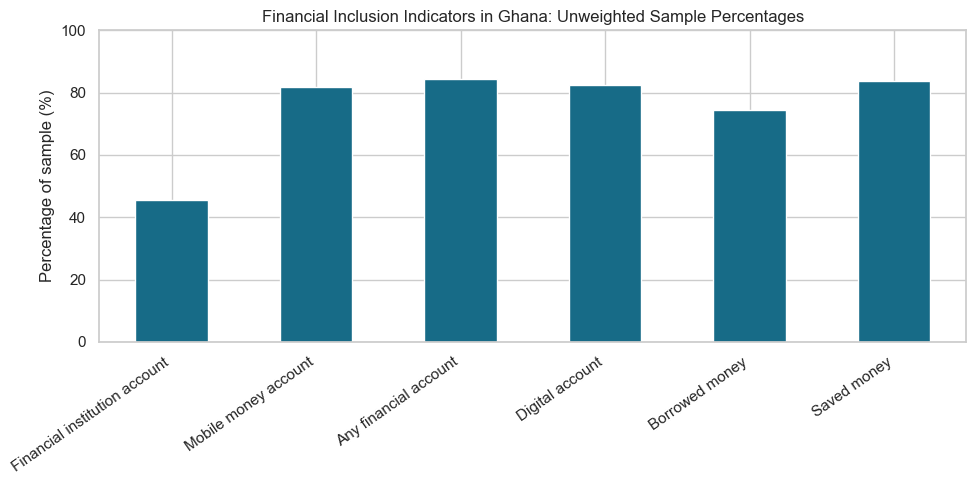

In [30]:
ax = financial_summary.plot.bar(x="Indicator", y="Yes (%)", legend=False, figsize=(10, 5), color="#176b87")
ax.set_ylabel("Percentage of sample (%)")
ax.set_xlabel("")
ax.set_title("Financial Inclusion Indicators in Ghana: Unweighted Sample Percentages")
ax.set_ylim(0, 100)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "financial_inclusion_indicators_unweighted.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Subgroup comparisons

The following function applies the same descriptive logic to gender, income quintile, education, employment, and residence. Numeric codes remain visible so that labels can be verified against the official codebook.

In [31]:
group_vars = {
    "Gender code": "female",
    "Income quintile": "inc_q",
    "Education code": "educ",
    "Employment code": "emp_in",
    "Urbanicity code": "urbanicity",
}

def subgroup_percentages(data, group_var, outcome_vars=financial_vars):
    rows = []
    for outcome in outcome_vars:
        grouped = data.groupby(group_var, dropna=False)[outcome].mean().mul(100)
        for group_value, percentage in grouped.items():
            rows.append({
                "Grouping": group_var,
                "Group": group_value,
                "Indicator": indicator_labels[outcome],
                "Variable": outcome,
                "Percentage (%)": percentage,
            })
    return pd.DataFrame(rows)

subgroup_results = []
for grouping, group_var in group_vars.items():
    result = subgroup_percentages(analysis_df, group_var)
    result["Grouping"] = grouping
    subgroup_results.append(result)
    print(f"\n{grouping}")
    display(result.pivot(index="Indicator", columns="Group", values="Percentage (%)").round(1))

subgroup_results = pd.concat(subgroup_results, ignore_index=True)
subgroup_results["Percentage (%)"] = subgroup_results["Percentage (%)"].round(1)
subgroup_results.to_csv(OUTPUT_TABLES / "financial_inclusion_subgroup_percentages.csv", index=False)


Gender code


Group,1,2
Indicator,,
Any financial account,81.7,86.7
Borrowed money,72.5,76.6
Digital account,79.9,85.2
Financial institution account,37.2,53.6
Mobile money account,79.1,84.4
Saved money,81.3,86.0



Income quintile


Group,1,2,3,4,5
Indicator,,,,,
Any financial account,69.7,76.9,82.5,90.0,94.7
Borrowed money,75.8,79.3,73.2,73.6,72.6
Digital account,67.9,74.6,80.9,89.1,92.8
Financial institution account,24.8,32.5,42.1,46.8,68.4
Mobile money account,67.3,73.4,79.8,88.2,92.4
Saved money,76.4,77.5,78.1,88.6,92.0



Education code


Group,NaN,1.0,2.0,3.0
Indicator,,,,
Any financial account,100.0,67.4,88.5,100.0
Borrowed money,50.0,73.1,75.2,75.0
Digital account,50.0,65.2,87.1,99.1
Financial institution account,50.0,22.3,45.8,97.4
Mobile money account,50.0,64.4,86.1,99.1
Saved money,100.0,73.1,85.6,97.4



Employment code


Group,1,2
Indicator,,
Any financial account,89.3,69.7
Borrowed money,78.3,63.8
Digital account,87.5,68.1
Financial institution account,56.2,14.6
Mobile money account,86.9,66.9
Saved money,89.4,66.9



Urbanicity code


Group,1,2
Indicator,,
Any financial account,80.0,89.3
Borrowed money,76.3,72.6
Digital account,78.0,88.0
Financial institution account,42.6,49.1
Mobile money account,77.6,86.7
Saved money,83.5,83.9


## 7. Weighted estimates

The Global Findex metadata state that weights support nationally representative estimates. This simple weighted mean is appropriate for descriptive proportions. It does not replace a full survey-design variance calculation; standard errors and confidence intervals require the relevant design information.

In [32]:
def weighted_mean_binary(data, outcome, weight=weight_var):
    subset = data[[outcome, weight]].dropna()
    subset = subset[subset[outcome].isin([0, 1])]
    if subset.empty or subset[weight].sum() == 0:
        return np.nan
    return np.average(subset[outcome], weights=subset[weight])

weighted_summary = pd.DataFrame({
    "Indicator": [indicator_labels[v] for v in financial_vars],
    "Variable": financial_vars,
    "Weighted yes (%)": [weighted_mean_binary(analysis_df, v) * 100 for v in financial_vars],
})
weighted_summary["Weighted yes (%)"] = weighted_summary["Weighted yes (%)"].round(1)
display(weighted_summary)
weighted_summary.to_csv(OUTPUT_TABLES / "financial_inclusion_summary_weighted.csv", index=False)

,Indicator,Variable,Weighted yes (%)
0,Financial institution account,account_fin,38.7
1,Mobile money account,account_mob,78.3
2,Any financial account,account,81.2
3,Digital account,dig_account,79.3
4,Borrowed money,borrowed,74.2
5,Saved money,saved,82.0


## 8. Statistical model

The primary outcome is `account`, indicating ownership of any financial account. Education is retained in the descriptive analysis. The adjusted model below excludes `educ` because the Ghana data show complete prediction for the highest education category in this sample; including it produces an unstable/infinite odds ratio rather than a credible estimate. This modelling decision is documented rather than hidden.

In [33]:
education_check = (
    analysis_df.groupby("educ")["account"]
    .agg(count="count", account_yes="sum", account_rate="mean")
    .reset_index()
)
education_check["account_rate (%)"] = education_check["account_rate"] * 100
display(education_check.round(3))
display(pd.crosstab(analysis_df["educ"], analysis_df["account"], margins=True))

model_vars = ["account", "female", "inc_q", "emp_in", "urbanicity", "wgt"]
model_df = analysis_df[model_vars].dropna().copy()
print("Original observations:", len(analysis_df))
print("Complete-case observations:", len(model_df))
print("Excluded observations:", len(analysis_df) - len(model_df))

,educ,count,account_yes,account_rate,account_rate (%)
0,1.0,264,178,0.674,67.424
1,2.0,618,547,0.885,88.511
2,3.0,116,116,1.000,100.000


account,0,1,All
educ,,,
1.0,86,178,264
2.0,71,547,618
3.0,0,116,116
All,157,841,998


Original observations: 1000
Complete-case observations: 1000
Excluded observations: 0


In [34]:
if smf is None or sm is None:
    raise ImportError("statsmodels is required for the regression section. Install requirements.txt and rerun.")

weighted_model_stable = smf.glm(
    "account ~ C(female) + C(inc_q) + C(emp_in) + C(urbanicity)",
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=model_df["wgt"],
).fit()

print(weighted_model_stable.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                account   No. Observations:                 1000
Model:                            GLM   Df Residuals:                   992.00
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -418.95
Date:                Tue, 01 Sep 2026   Deviance:                       837.90
Time:                        19:48:21   Pearson chi2:                     936.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1197
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.7389      0

In [35]:
stable_results = pd.DataFrame({
    "Odds Ratio": np.exp(weighted_model_stable.params),
    "CI Lower": np.exp(weighted_model_stable.conf_int()[0]),
    "CI Upper": np.exp(weighted_model_stable.conf_int()[1]),
    "p-value": weighted_model_stable.pvalues,
})
stable_results["Significance"] = np.select(
    [stable_results["p-value"] < 0.001, stable_results["p-value"] < 0.01, stable_results["p-value"] < 0.05],
    ["***", "**", "*"],
    default="",
)
stable_results = stable_results.round({"Odds Ratio": 3, "CI Lower": 3, "CI Upper": 3, "p-value": 3})
display(stable_results)
stable_results.to_csv(OUTPUT_TABLES / "weighted_logistic_regression_odds_ratios.csv")

,Odds Ratio,CI Lower,CI Upper,p-value,Significance
Intercept,2.094,1.445,3.033,0.000,***
C(female)[T.2],1.270,0.898,1.797,0.177,
C(inc_q)[T.2],1.589,1.013,2.491,0.044,*
C(inc_q)[T.3],2.472,1.523,4.013,0.000,***
C(inc_q)[T.4],4.107,2.336,7.222,0.000,***
C(inc_q)[T.5],7.010,3.557,13.813,0.000,***
C(emp_in)[T.2],0.338,0.239,0.477,0.000,***
C(urbanicity)[T.2],1.831,1.273,2.634,0.001,**


In [36]:
mcfadden_r2 = 1 - (weighted_model_stable.llf / weighted_model_stable.llnull)
model_fit = pd.DataFrame({
    "Statistic": ["AIC", "Deviance", "Pearson Chi-square", "McFadden Pseudo R-squared"],
    "Value": [weighted_model_stable.aic, weighted_model_stable.deviance, weighted_model_stable.pearson_chi2, mcfadden_r2],
})
display(model_fit.round(3))
model_fit.to_csv(OUTPUT_TABLES / "weighted_logistic_model_fit.csv", index=False)

,Statistic,Value
0,AIC,853.897
1,Deviance,837.897
2,Pearson Chi-square,936.276
3,McFadden Pseudo R-squared,0.132


## 9. Model-based predicted probabilities

Predictions are shown for clearly stated covariate profiles. They are conditional predictions, not subgroup population means.

,inc_q,female,emp_in,urbanicity,predicted_probability (%)
0,1,1,1,2,79.31
1,2,1,1,2,85.90
2,3,1,1,2,90.46
3,4,1,1,2,94.03
4,5,1,1,2,96.41


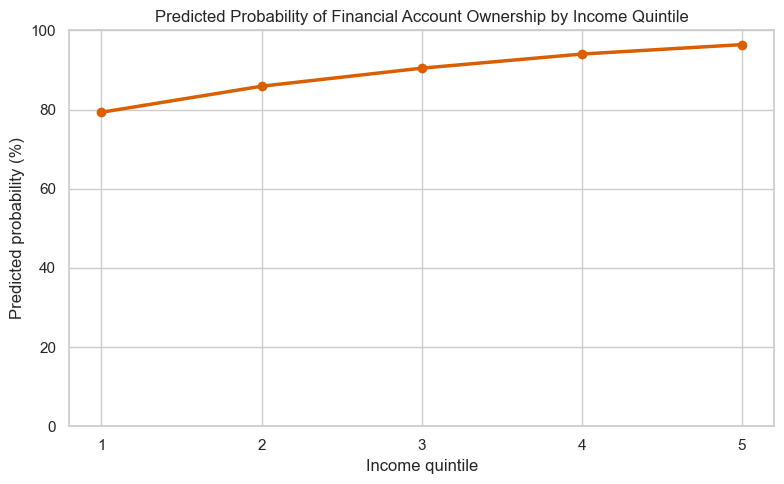

In [37]:
prediction_data = pd.DataFrame({
    "inc_q": [1, 2, 3, 4, 5],
    "female": [1] * 5,
    "emp_in": [1] * 5,
    "urbanicity": [2] * 5,
})
prediction_data["predicted_probability (%)"] = weighted_model_stable.predict(prediction_data) * 100
display(prediction_data.round(2))
prediction_data.to_csv(OUTPUT_TABLES / "predicted_probability_by_income_quintile.csv", index=False)

ax = prediction_data.plot(x="inc_q", y="predicted_probability (%)", marker="o", linewidth=2.5, legend=False, figsize=(8, 5), color="#d95f02")
ax.set_xlabel("Income quintile")
ax.set_ylabel("Predicted probability (%)")
ax.set_title("Predicted Probability of Financial Account Ownership by Income Quintile")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "predicted_probability_by_income_quintile.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
employment_prediction = pd.DataFrame({
    "inc_q": [3, 3], "female": [1, 1], "emp_in": [1, 2], "urbanicity": [2, 2]
})
employment_prediction["predicted_probability (%)"] = weighted_model_stable.predict(employment_prediction) * 100
display(employment_prediction.round(2))

urbanicity_prediction = pd.DataFrame({
    "inc_q": [3, 3], "female": [1, 1], "emp_in": [1, 1], "urbanicity": [1, 2]
})
urbanicity_prediction["predicted_probability (%)"] = weighted_model_stable.predict(urbanicity_prediction) * 100
display(urbanicity_prediction.round(2))

,inc_q,female,emp_in,urbanicity,predicted_probability (%)
0,3,1,1,2,90.46
1,3,1,2,2,76.19


,inc_q,female,emp_in,urbanicity,predicted_probability (%)
0,3,1,1,1,83.81
1,3,1,1,2,90.46


## 10. Interpretation, limitations, and conclusion


### Interpretation template

The descriptive results indicate that **[insert the observed pattern]**. Differences across **[insert groups]** are especially notable for **[insert indicators]**. In the weighted logistic model, **[insert statistically significant predictors]** are associated with account ownership, while **[insert non-significant predictors]** are not statistically distinguishable from the reference category at the chosen threshold.

These associations should not be interpreted as causal effects. The cross-sectional survey design does not establish temporal ordering, and the model may omit relevant factors. The sample percentages and model estimates should be read alongside the World Bank documentation on sampling, weighting, and sampling error.

### Limitations

The analysis uses one Ghana survey round and does not estimate trends over time. The compact workflow uses weights for descriptive estimates and a weighted GLM for a sensitivity-oriented adjusted model, but it does not reproduce the full complex-survey variance structure. Education is excluded from the adjusted model because of complete prediction in one category; this prevents an unstable coefficient but also means education is not controlled for in that specification.

### Conclusion

This notebook documents a transparent, reproducible first analysis of Ghanaian financial inclusion. It separates data inspection, recoding, descriptive estimates, subgroup comparisons, weighted estimates, modelling, diagnostics, and interpretation. Future work can add design-based standard errors, alternative outcomes such as mobile-money ownership, and comparisons with earlier Global Findex rounds.